# Loan Approval Prediction System

In [1]:
!pip install numpy pandas matplotlib seaborn scikit-learn

In [39]:
from __future__ import annotations

import os
from typing import Any

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
     accuracy_score,
     classification_report,
     confusion_matrix,
     f1_score,
     precision_score,
     recall_score,
     roc_auc_score
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

## Creating Synthetic dataset

In [3]:
def create_loan_dataset(
    n_samples: int = 1200,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)

    applicant_income = rng.integers(
        25_000,
        200_000,
        n_samples,
    )

    loan_amount = rng.integers(
        10_000,
        160_000,
        n_samples,
    )

    credit_score = np.clip(
        rng.normal(650, 85, n_samples),
        300,
        850,
    ).round().astype(int)

    existing_debt = rng.integers(
        0,
        120_000,
        n_samples,
    )

    employment_years = np.clip(
        rng.normal(6, 4, n_samples),
        0,
        35,
    ).round(1)

    loan_term = rng.choice(
        [12, 24, 36, 48, 60],
        n_samples,
        p=[0.10, 0.20, 0.35, 0.20, 0.15],
    )

    employment_type = rng.choice(
        ["Salaried", "Self-employed", "Contract"],
        n_samples,
        p=[0.60, 0.25, 0.15],
    )

    education = rng.choice(
        ["High School", "Graduate", "Postgraduate"],
        n_samples,
        p=[0.25, 0.55, 0.20],
    )

    property_area = rng.choice(
        ["Urban", "Semiurban", "Rural"],
        n_samples,
        p=[0.45, 0.35, 0.20],
    )

    self_employed = np.where(
        employment_type == "Self-employed",
        "Yes",
        rng.choice(
            ["No", "Yes"],
            n_samples,
            p=[0.95, 0.05],
        ),
    )

    debt_to_income = (
        existing_debt
        / np.maximum(applicant_income, 1)
    )

    score = (
        0.012 * (credit_score - 650)
        + 0.000012 * (applicant_income - 80_000)
        - 0.000014 * (loan_amount - 60_000)
        - 1.8 * debt_to_income
        + 0.09 * employment_years
        + np.where(
            employment_type == "Salaried",
            0.35,
            np.where(
                employment_type == "Self-employed",
                0.10,
                -0.25,
            ),
        )
        + np.where(
            education == "Postgraduate",
            0.20,
            np.where(
                education == "Graduate",
                0.10,
                -0.10,
            ),
        )
        + np.where(
            property_area == "Urban",
            0.08,
            0.0,
        )
        + rng.normal(0, 0.9, n_samples)
        - 0.80
    )

    approval_probability = 1 / (
        1 + np.exp(-score)
    )

    loan_approved = (
        rng.random(n_samples)
        < approval_probability
    ).astype(int)

    df = pd.DataFrame({
        "applicant_income": applicant_income,
        "loan_amount": loan_amount,
        "credit_score": credit_score,
        "existing_debt": existing_debt,
        "employment_years": employment_years,
        "loan_term": loan_term,
        "employment_type": employment_type,
        "education": education,
        "property_area": property_area,
        "self_employed": self_employed,
        "loan_approved": loan_approved,
    })

    # Add a few missing values to simulate raw data.
    missing_columns = [
        "credit_score",
        "employment_years",
        "employment_type",
        "education",
    ]

    for column in missing_columns:
        missing_indices = rng.choice(
            n_samples,
            size=int(0.03 * n_samples),
            replace=False,
        )
        df.loc[missing_indices, column] = np.nan

    return df

## create and Inspect Data
df = create_loan_dataset()

print("First five rows:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution:")
print(df["loan_approved"].value_counts())

print("\nTarget percentage:")
print(
    df["loan_approved"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

First five rows:
   applicant_income  loan_amount  credit_score  existing_debt  \
0             40618       141853         566.0         110200   
1            160442        81625         577.0          58453   
2            139550       157714         850.0          41817   
3            101803       124214         803.0          12874   
4            100777       107632         615.0          46767   

   employment_years  loan_term employment_type     education property_area  \
0               7.7         48        Contract      Graduate         Urban   
1               8.9         24        Salaried   High School         Urban   
2              10.7         60   Self-employed   High School     Semiurban   
3               1.3         12        Salaried           NaN         Urban   
4               9.0         24        Salaried  Postgraduate         Urban   

  self_employed  loan_approved  
0            No              0  
1            No              1  
2           Yes         

## feature Engineering

In [5]:
x = df.drop(
    columns="loan_approved"
)

y = df["loan_approved"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1200, 10)
Target shape: (1200,)


## Train Validation and Test

In [6]:
X_train,X_test,y_train,y_test=(train_test_split(
     x,y,
     test_size=0.20,
     random_state=42,
     stratify=y,
))
X_train_valid,X_test_valid,y_train_valid,y_test_valid=(train_test_split(
     X_train,y_train,
     test_size=0.25,
     random_state=42
))
print("Training size:", len(X_train))
print("Validation size:", len(X_train_valid))
print("Testing size:", len(X_test))


Training size: 960
Validation size: 720
Testing size: 240


## Check Class proportion

In [7]:
def print_class_distribution(
    name: str,
    target: pd.Series,
) -> None:
    distribution = (
        target
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
        .round(2)
    )

    print(f"\n{name}:")
    print(distribution)


print_class_distribution(
    "Training distribution",
    y_train,
)

print_class_distribution(
    "Validation distribution",
    y_train_valid,
)

print_class_distribution(
    "Test distribution",
    y_test,
)


Training distribution:
loan_approved
0    66.35
1    33.65
Name: proportion, dtype: float64

Validation distribution:
loan_approved
0    67.36
1    32.64
Name: proportion, dtype: float64

Test distribution:
loan_approved
0    66.25
1    33.75
Name: proportion, dtype: float64


## Defining Column Groups

In [8]:
numerical_features = [
    "applicant_income",
    "loan_amount",
    "credit_score",
    "existing_debt",
    "employment_years",
    "loan_term",
]

categorical_features = [
    "employment_type",
    "education",
    "property_area",
    "self_employed",
]

## Numerical and Categorical Pipeline

In [9]:
num_pipe=Pipeline(steps=[
     ("imputer",SimpleImputer(strategy="median")),
     ("scaler",StandardScaler())
])
cat_pipe=Pipeline(steps=[
     ("imputer",SimpleImputer(strategy="most_frequent")),
     ("encoding",OneHotEncoder(handle_unknown="ignore",sparse_output=False))
])

## Column Transformer

In [10]:
preproc=ColumnTransformer(transformers=[
     ("numerical",num_pipe,numerical_features),
     ("categorical",cat_pipe,categorical_features)
],sparse_threshold=0,
)

## Model Usuage

In [11]:
models = {
    "Logistic Regression": LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=42,
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=9,
        weights="distance",
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=42,
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=5,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),

    "Gaussian Naive Bayes": GaussianNB(),
}

## Probability helper

In [13]:
def get_positive_probabilities(
    fitted_pipeline: Pipeline,
    features: pd.DataFrame,
) -> np.ndarray:
    classifier = fitted_pipeline.named_steps["model"]

    classes = list(classifier.classes_)

    if 1 not in classes:
        raise ValueError(
            "Positive class 1 was not learned."
        )

    positive_index = classes.index(1)

    return fitted_pipeline.predict_proba(
        features
    )[:, positive_index]

## Evaluation Function

In [14]:
def evaluate_model(
    model_name: str,
    fitted_pipeline: Pipeline,
    features: pd.DataFrame,
    target: pd.Series,
    threshold: float = 0.50,
) -> dict[str, Any]:
    probabilities = get_positive_probabilities(
        fitted_pipeline,
        features,
    )

    predictions = (
        probabilities >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        target,
        predictions,
        labels=[0, 1],
    ).ravel()

    return {
        "Model": model_name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            target,
            predictions,
        ),
        "Precision": precision_score(
            target,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            target,
            predictions,
            zero_division=0,
        ),
        "F1": f1_score(
            target,
            predictions,
            zero_division=0,
        ),
        "ROC_AUC": roc_auc_score(
            target,
            probabilities,
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

## Model training

In [15]:
trained_pipelines: dict[str, Pipeline] = {}
validation_results: list[dict[str, Any]] = []

for model_name, estimator in models.items():
    model_pipeline = Pipeline(steps=[
        (
            "preprocessor",
            clone(preproc),
        ),
        (
            "model",
            estimator,
        ),
    ])

    model_pipeline.fit(
        X_train,
        y_train,
    )

    trained_pipelines[model_name] = (
        model_pipeline
    )

    result = evaluate_model(
        model_name=model_name,
        fitted_pipeline=model_pipeline,
        features=X_train_valid,
        target=y_train_valid,
        threshold=0.50,
    )

    validation_results.append(result)

## validation Comparison table

In [17]:
validation_results_df = pd.DataFrame(
    validation_results
).sort_values(
    by="ROC_AUC",
    ascending=False,
)

metric_columns = [
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC_AUC",
    "FP",
    "FN",
]

print("\nValidation comparison:")

validation_results_df[
     metric_columns
].round(4)


Validation comparison:


,Model,Accuracy,Precision,Recall,F1,ROC_AUC,FP,FN
1,K-Nearest Neighbors,1.0000,1.0000,1.0000,1.0000,1.0000,0,0
3,Random Forest,0.8931,0.7705,0.9574,0.8539,0.9712,67,10
2,Decision Tree,0.7903,0.6382,0.8255,0.7199,0.8816,110,41
0,Logistic Regression,0.7875,0.6367,0.8128,0.7140,0.8733,109,44
4,Gaussian Naive Bayes,0.7708,0.6966,0.5277,0.6005,0.8607,54,111


## Best ranking Model

In [18]:
best_model_name = (
    validation_results_df
    .iloc[0]["Model"]
)

best_model = trained_pipelines[
    best_model_name
]

print(
    "\nBest validation ranking model:",
    best_model_name,
)


Best validation ranking model: K-Nearest Neighbors


## Threshold Section

In [19]:
false_positive_cost = 5
false_negative_cost = 2

validation_probabilities = (
    get_positive_probabilities(
        best_model,
        X_train_valid,
    )
)

threshold_results = []

for threshold in np.arange(
    0.20,
    0.81,
    0.05,
):
    threshold = round(
        float(threshold),
        2,
    )

    predictions = (
        validation_probabilities
        >= threshold
    ).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_train_valid,
        predictions,
        labels=[0, 1],
    ).ravel()

    business_cost = (
        fp * false_positive_cost
        + fn * false_negative_cost
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_train_valid,
            predictions,
        ),
        "Precision": precision_score(
            y_train_valid,
            predictions,
            zero_division=0,
        ),
        "Recall": recall_score(
            y_train_valid,
            predictions,
            zero_division=0,
        ),
        "F1": f1_score(
            y_train_valid,
            predictions,
            zero_division=0,
        ),
        "FP": fp,
        "FN": fn,
        "Business_Cost": business_cost,
    })

## Creating Table

In [20]:
threshold_results_df = pd.DataFrame(
    threshold_results
).sort_values(
    by=[
        "Business_Cost",
        "F1",
    ],
    ascending=[
        True,
        False,
    ],
)

print("\nThreshold comparison:")
print(
    threshold_results_df.round(4)
)


Threshold comparison:
    Threshold  Accuracy  Precision  Recall   F1  FP  FN  Business_Cost
0        0.20       1.0        1.0     1.0  1.0   0   0              0
1        0.25       1.0        1.0     1.0  1.0   0   0              0
2        0.30       1.0        1.0     1.0  1.0   0   0              0
3        0.35       1.0        1.0     1.0  1.0   0   0              0
4        0.40       1.0        1.0     1.0  1.0   0   0              0
5        0.45       1.0        1.0     1.0  1.0   0   0              0
6        0.50       1.0        1.0     1.0  1.0   0   0              0
7        0.55       1.0        1.0     1.0  1.0   0   0              0
8        0.60       1.0        1.0     1.0  1.0   0   0              0
9        0.65       1.0        1.0     1.0  1.0   0   0              0
10       0.70       1.0        1.0     1.0  1.0   0   0              0
11       0.75       1.0        1.0     1.0  1.0   0   0              0
12       0.80       1.0        1.0     1.0  1.0   0   

## Selection Threshold

In [21]:
best_threshold = float(
    threshold_results_df
    .iloc[0]["Threshold"]
)

print(
    "\nSelected threshold:",
    best_threshold,
)


Selected threshold: 0.2


## Final test Evalutaion

In [23]:
final_result = evaluate_model(
    model_name=best_model_name,
    fitted_pipeline=best_model,
    features=X_test,
    target=y_test,
    threshold=best_threshold,
)

final_result_df = pd.DataFrame(
    [final_result]
)

print("\nFinal test result:")
print(
    final_result_df[
        metric_columns
    ].round(4)
)


Final test result:
                 Model  Accuracy  Precision  Recall     F1  ROC_AUC  FP  FN
0  K-Nearest Neighbors     0.625     0.4717  0.9259  0.625     0.76  84   6


## Print Final Report

In [25]:
test_probabilities = (
    get_positive_probabilities(
        best_model,
        X_test,
    )
)

test_predictions = (
    test_probabilities
    >= best_threshold
).astype(int)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_test,
        test_predictions,
        target_names=[
            "Rejected",
            "Approved",
        ],
        zero_division=0,
    )
)

print("\nFinal Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        test_predictions,
        labels=[0, 1],
    )
)


Final Classification Report:
              precision    recall  f1-score   support

    Rejected       0.93      0.47      0.62       159
    Approved       0.47      0.93      0.62        81

    accuracy                           0.62       240
   macro avg       0.70      0.70      0.62       240
weighted avg       0.77      0.62      0.62       240


Final Confusion Matrix:
[[75 84]
 [ 6 75]]


## Error Analysis table

In [29]:
error_analysis_df = X_test.copy()

error_analysis_df["Actual"] = (
    y_test
)

error_analysis_df["Predicted"] = (
    test_predictions
)

error_analysis_df[
    "Approval_Probability"
] = test_probabilities

error_analysis_df[
    "Prediction_Type"
] = [
    (
        "TN"
        if actual == 0 and predicted == 0
        else "FP"
        if actual == 0 and predicted == 1
        else "FN"
        if actual == 1 and predicted == 0
        else "TP"
    )
    for actual, predicted in zip(
        y_test,
        test_predictions,
    )
]

print("\nFalse Positives:")
print(
    error_analysis_df[
        error_analysis_df[
            "Prediction_Type"
        ] == "FP"
    ].head()
)

print("\nFalse Negatives:")
print(
    error_analysis_df[
        error_analysis_df[
            "Prediction_Type"
        ] == "FN"
    ].head()
)


False Positives:
      applicant_income  loan_amount  credit_score  existing_debt  \
756             154060        89294         557.0          55113   
959              97066        60116         656.0          73234   
209             161281        52487         514.0          65833   
99               49456        14441         612.0          71072   
1051             88860        92827         651.0           1342   

      employment_years  loan_term employment_type    education property_area  \
756                2.9         24        Salaried          NaN     Semiurban   
959                0.0         36        Salaried     Graduate         Urban   
209               16.7         48        Salaried     Graduate     Semiurban   
99                 7.9         24        Salaried  High School     Semiurban   
1051               3.4         36        Salaried     Graduate         Urban   

     self_employed  Actual  Predicted  Approval_Probability Prediction_Type  
756           

## Save the full System

In [30]:
os.makedirs(
    "models",
    exist_ok=True,
)

model_bundle = {
    "model": best_model,
    "threshold": best_threshold,
    "feature_columns": X.columns.tolist(),
    "class_mapping": {
        0: "Rejected",
        1: "Approved",
    },
}

model_path = (
    "models/"
    "loan_approval_model.joblib"
)

joblib.dump(
    model_bundle,
    model_path,
)

print(
    f"\nModel saved to: {model_path}"
)


Model saved to: models/loan_approval_model.joblib


## Load the Model

In [31]:
loaded_bundle = joblib.load(
    model_path
)

loaded_model = loaded_bundle["model"]

loaded_threshold = loaded_bundle[
    "threshold"
]

loaded_feature_columns = loaded_bundle[
    "feature_columns"
]

## Input Validation

In [32]:
def validate_application(
    application: dict[str, Any],
) -> pd.DataFrame:
    required_columns = [
        "applicant_income",
        "loan_amount",
        "credit_score",
        "existing_debt",
        "employment_years",
        "loan_term",
        "employment_type",
        "education",
        "property_area",
        "self_employed",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in application
    ]

    if missing_columns:
        raise ValueError(
            "Missing required fields: "
            + ", ".join(missing_columns)
        )

    if application["applicant_income"] <= 0:
        raise ValueError(
            "applicant_income must be positive"
        )

    if application["loan_amount"] <= 0:
        raise ValueError(
            "loan_amount must be positive"
        )

    if not (
        300
        <= application["credit_score"]
        <= 850
    ):
        raise ValueError(
            "credit_score must be between 300 and 850"
        )

    if application["existing_debt"] < 0:
        raise ValueError(
            "existing_debt cannot be negative"
        )

    if application["employment_years"] < 0:
        raise ValueError(
            "employment_years cannot be negative"
        )

    valid_terms = {
        12,
        24,
        36,
        48,
        60,
    }

    if application["loan_term"] not in valid_terms:
        raise ValueError(
            "loan_term must be one of "
            "12, 24, 36, 48 or 60"
        )

    valid_employment_types = {
        "Salaried",
        "Self-employed",
        "Contract",
    }

    if (
        application["employment_type"]
        not in valid_employment_types
    ):
        raise ValueError(
            "Invalid employment_type"
        )

    valid_education = {
        "High School",
        "Graduate",
        "Postgraduate",
    }

    if (
        application["education"]
        not in valid_education
    ):
        raise ValueError(
            "Invalid education value"
        )

    valid_property_areas = {
        "Urban",
        "Semiurban",
        "Rural",
    }

    if (
        application["property_area"]
        not in valid_property_areas
    ):
        raise ValueError(
            "Invalid property_area"
        )

    if application["self_employed"] not in {
        "Yes",
        "No",
    }:
        raise ValueError(
            "self_employed must be Yes or No"
        )

    return pd.DataFrame(
        [application],
        columns=required_columns,
    )

## Production Prediction Function

In [33]:
def predict_loan_approval(
    application: dict[str, Any],
    bundle: dict[str, Any],
) -> dict[str, Any]:
    input_df = validate_application(
        application
    )

    fitted_model = bundle["model"]
    threshold = bundle["threshold"]

    probability = float(
        get_positive_probabilities(
            fitted_model,
            input_df,
        )[0]
    )

    predicted_class = int(
        probability >= threshold
    )

    class_name = bundle[
        "class_mapping"
    ][predicted_class]

    return {
        "decision": class_name,
        "approval_probability": probability,
        "threshold": threshold,
        "message": (
            "This estimate is decision support "
            "and must not replace formal review."
        ),
    }

## Test by new value

In [36]:
new_application = {
    "applicant_income": 110_000,
    "loan_amount": 60_000,
    "credit_score": 730,
    "existing_debt": 20_000,
    "employment_years": 7,
    "loan_term": 36,
    "employment_type": "Salaried",
    "education": "Graduate",
    "property_area": "Urban",
    "self_employed": "No",
}

prediction_result = (
    predict_loan_approval(
        new_application,
        loaded_bundle,
    )
)

print("\nNew application result:")
prediction_result


New application result:


{'decision': 'Approved',
 'approval_probability': 0.8976168507363976,
 'threshold': 0.2,
 'message': 'This estimate is decision support and must not replace formal review.'}

## Save Project Output

In [37]:
os.makedirs(
    "reports",
    exist_ok=True,
)

validation_results_df.to_csv(
    "reports/model_comparison.csv",
    index=False,
)

threshold_results_df.to_csv(
    "reports/threshold_comparison.csv",
    index=False,
)

error_analysis_df.to_csv(
    "reports/error_analysis.csv",
    index=False,
)

## Save Dataset

In [38]:
os.makedirs(
    "data",
    exist_ok=True,
)

df.to_csv(
    "data/synthetic_loan_applications.csv",
    index=False,
)

## Folder for chart generation

In [40]:
import os

os.makedirs(
    "reports/figures",
    exist_ok=True
)

## Target Class Distribution

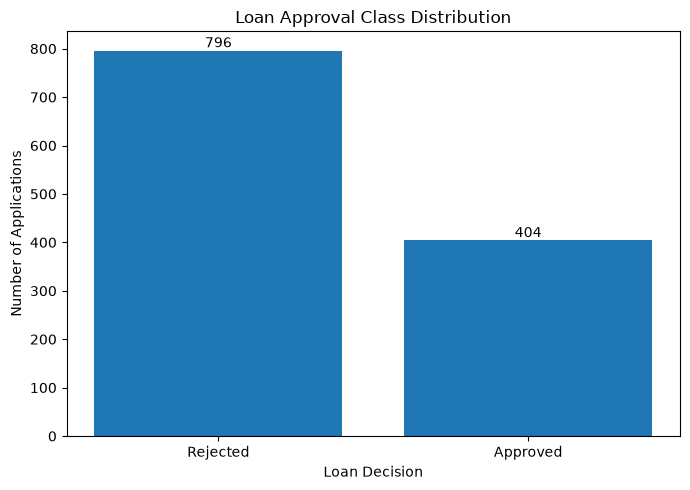

In [41]:
class_counts = (
    df["loan_approved"]
    .value_counts()
    .sort_index()
)

class_names = [
    "Rejected",
    "Approved"
]

plt.figure(figsize=(7, 5))

plt.bar(
    class_names,
    class_counts.values
)

plt.title("Loan Approval Class Distribution")
plt.xlabel("Loan Decision")
plt.ylabel("Number of Applications")

for index, count in enumerate(class_counts.values):
    plt.text(
        index,
        count,
        str(count),
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Class Distribution percentage

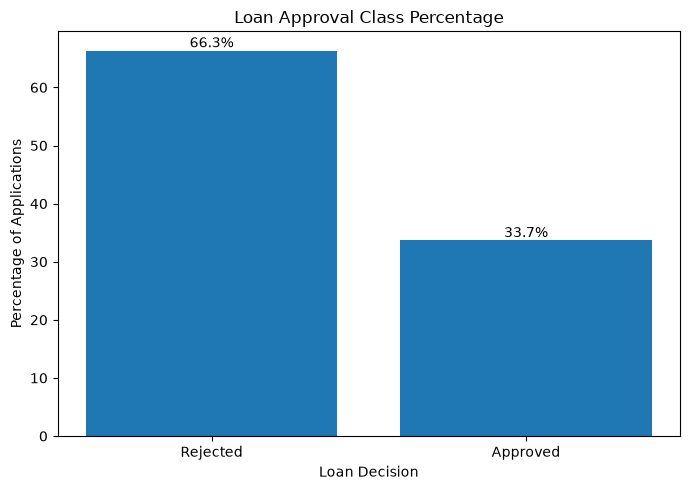

In [43]:
class_percentage = (
    df["loan_approved"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

plt.figure(figsize=(7, 5))

plt.bar(
    class_names,
    class_percentage.values
)

plt.title("Loan Approval Class Percentage")
plt.xlabel("Loan Decision")
plt.ylabel("Percentage of Applications")

for index, percentage in enumerate(
    class_percentage.values
):
    plt.text(
        index,
        percentage,
        f"{percentage:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/class_percentage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Numerical Feature Distribution

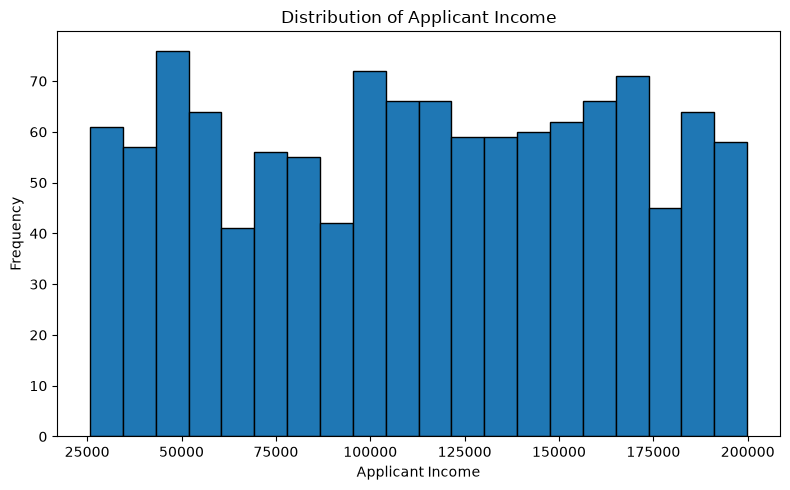

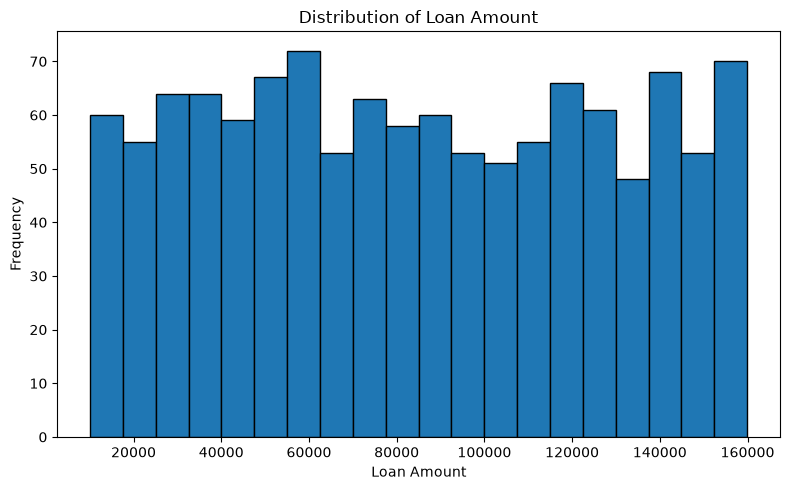

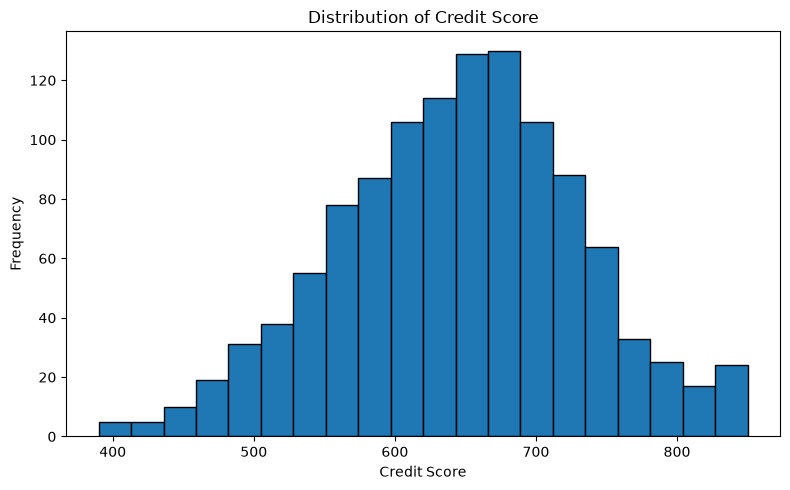

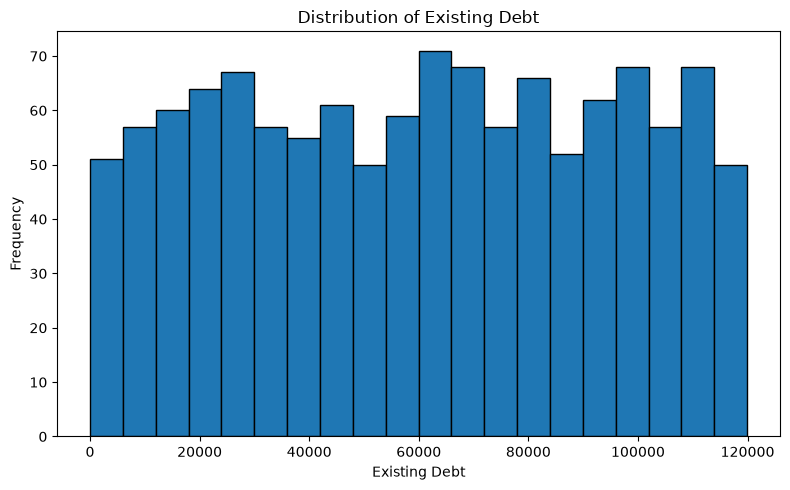

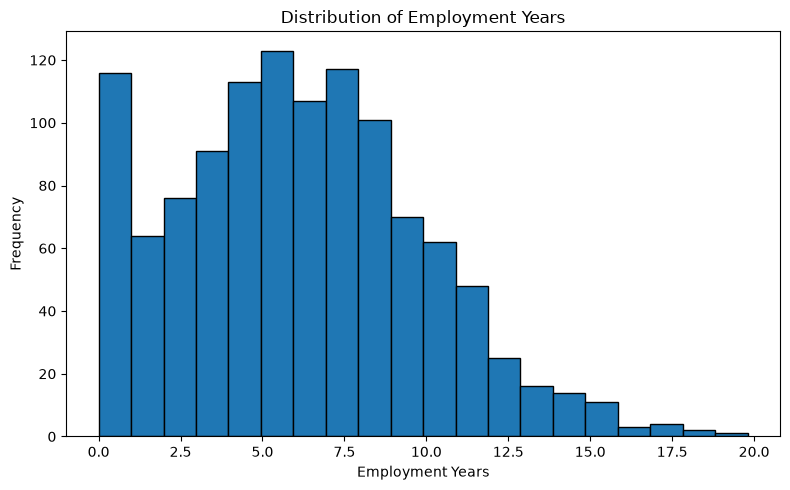

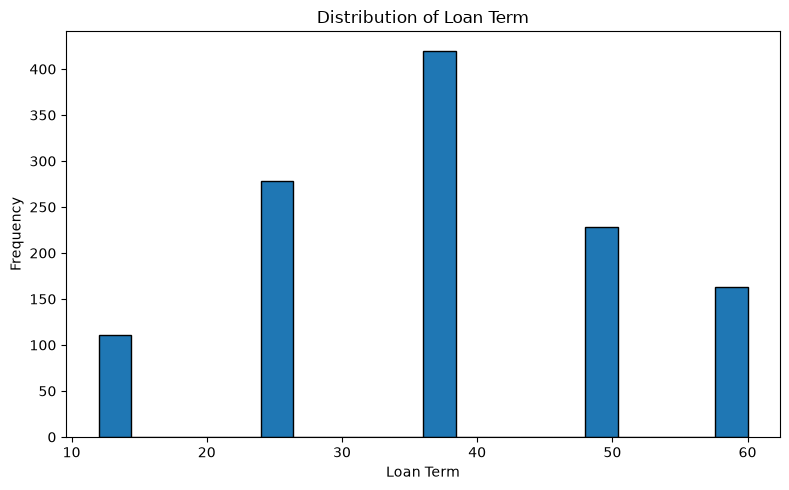

In [44]:
numerical_features = [
    "applicant_income",
    "loan_amount",
    "credit_score",
    "existing_debt",
    "employment_years",
    "loan_term"
]

for feature in numerical_features:
    plt.figure(figsize=(8, 5))

    plt.hist(
        df[feature].dropna(),
        bins=20,
        edgecolor="black"
    )

    readable_name = feature.replace(
        "_",
        " "
    ).title()

    plt.title(
        f"Distribution of {readable_name}"
    )

    plt.xlabel(readable_name)
    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        f"reports/figures/{feature}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

## credit Score by Loan Decision

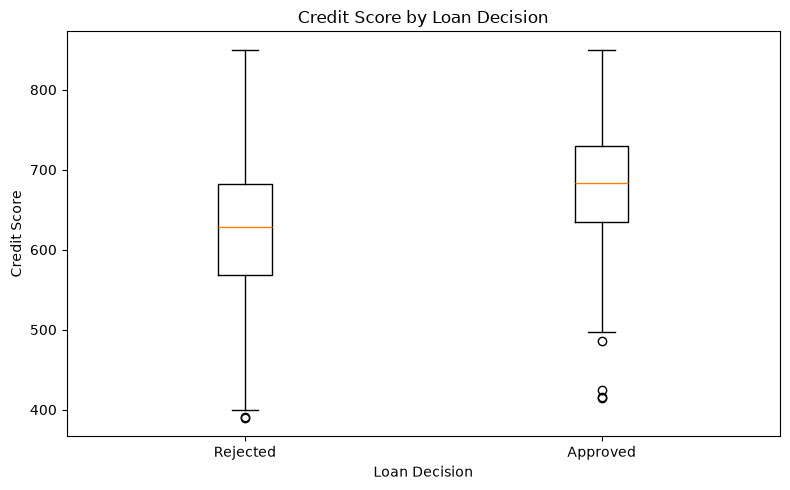

In [45]:
rejected_credit_scores = (
    df.loc[
        df["loan_approved"] == 0,
        "credit_score"
    ]
    .dropna()
)

approved_credit_scores = (
    df.loc[
        df["loan_approved"] == 1,
        "credit_score"
    ]
    .dropna()
)

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        rejected_credit_scores,
        approved_credit_scores
    ],
    tick_labels=[
        "Rejected",
        "Approved"
    ]
)

plt.title(
    "Credit Score by Loan Decision"
)

plt.xlabel("Loan Decision")
plt.ylabel("Credit Score")

plt.tight_layout()

plt.savefig(
    "reports/figures/credit_score_by_decision.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Applicant Income vs Loan Amount

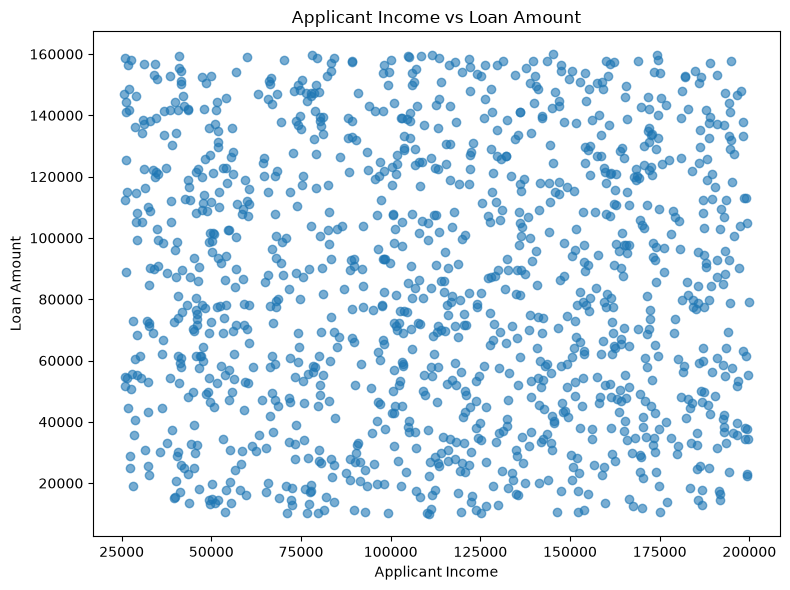

In [46]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["applicant_income"],
    df["loan_amount"],
    alpha=0.6
)

plt.title(
    "Applicant Income vs Loan Amount"
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

plt.tight_layout()

plt.savefig(
    "reports/figures/income_vs_loan_amount.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Approval rate by Employement type

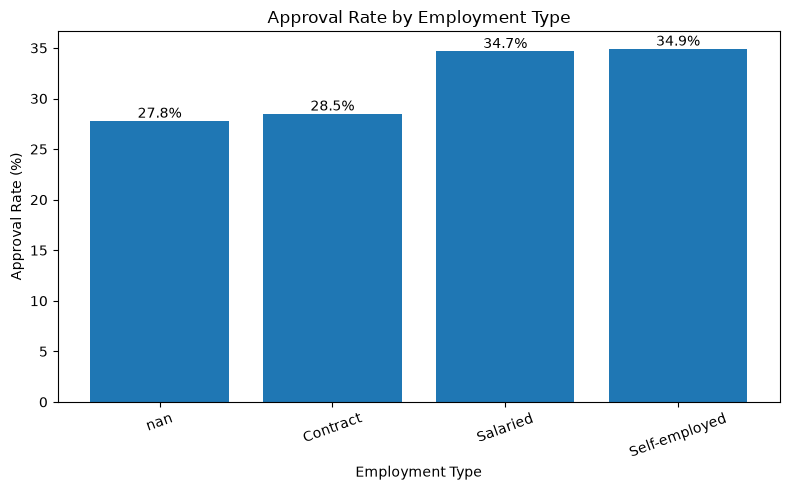

In [49]:
employment_approval_rate = (
    df.groupby(
        "employment_type",
        dropna=False
    )["loan_approved"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

x_labels = employment_approval_rate.index.astype(str)
x_positions = np.arange(len(x_labels))

plt.bar(
     x_positions,
     employment_approval_rate.values,
)

plt.xticks(
     x_positions,
     x_labels,
     rotation=20,
)

plt.title(
    "Approval Rate by Employment Type"
)

plt.xlabel("Employment Type")
plt.ylabel("Approval Rate (%)")

plt.xticks(rotation=20)

for index, value in enumerate(
    employment_approval_rate.values
):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "approval_rate_by_employment_type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Approval rate by Education

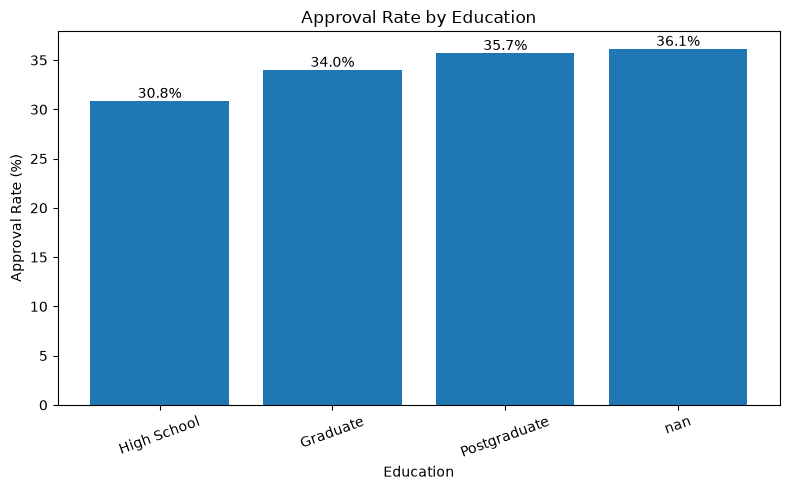

In [52]:
education_approval_rate = (
    df.groupby(
        "education",
        dropna=False
    )["loan_approved"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

x_labels = education_approval_rate.index.astype(str)
x_positions = np.arange(len(x_labels))

plt.bar(
    x_positions,
    education_approval_rate.values,
)

plt.xticks(
    x_positions,
    x_labels,
    rotation=20,
)

plt.title(
    "Approval Rate by Education"
)

plt.xlabel("Education")
plt.ylabel("Approval Rate (%)")

plt.xticks(rotation=20)

for index, value in enumerate(
    education_approval_rate.values
):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "approval_rate_by_education.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Approval Rate by Property

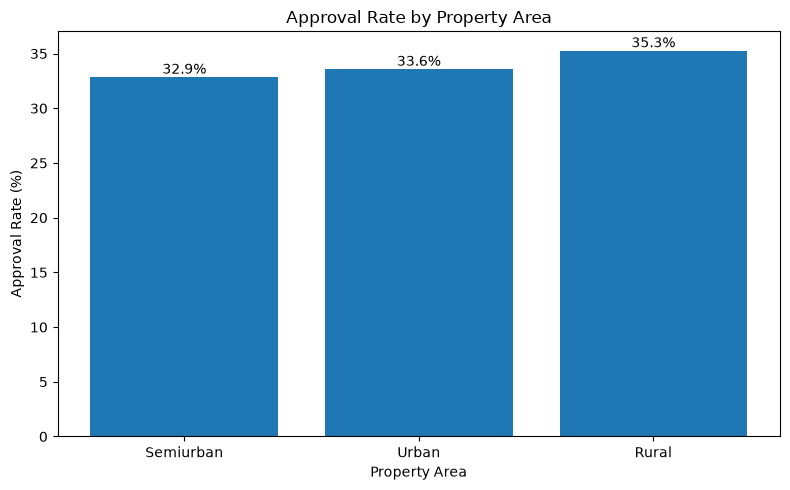

In [54]:
property_approval_rate = (
    df.groupby(
        "property_area",
        dropna=False
    )["loan_approved"]
    .mean()
    .mul(100)
    .sort_values()
)

plt.figure(figsize=(8, 5))

plt.bar(
    property_approval_rate.index.astype(str),
    property_approval_rate.values
)

plt.title(
    "Approval Rate by Property Area"
)

plt.xlabel("Property Area")
plt.ylabel("Approval Rate (%)")

for index, value in enumerate(
    property_approval_rate.values
):
    plt.text(
        index,
        value,
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "approval_rate_by_property_area.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Missing Value Visualisation

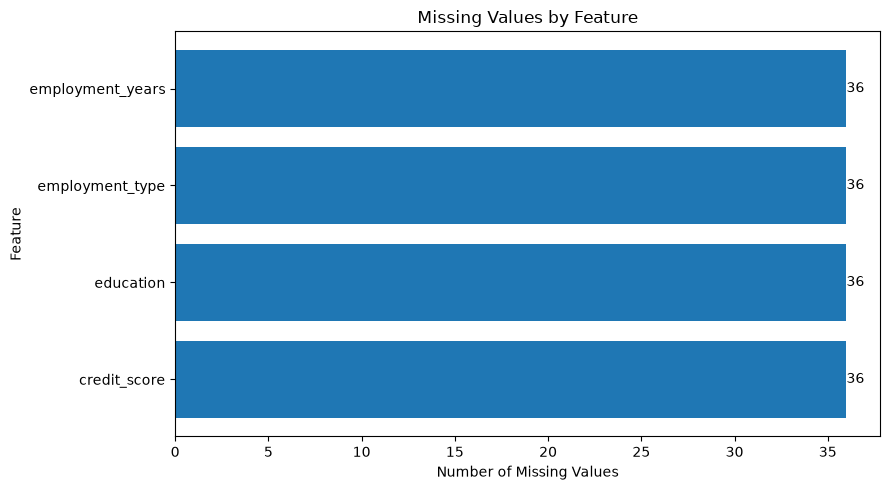

In [55]:
missing_counts = (
    df.isnull()
    .sum()
    .sort_values()
)

missing_counts = missing_counts[
    missing_counts > 0
]

plt.figure(figsize=(9, 5))

plt.barh(
    missing_counts.index,
    missing_counts.values
)

plt.title("Missing Values by Feature")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")

for index, value in enumerate(
    missing_counts.values
):
    plt.text(
        value,
        index,
        str(value),
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/missing_values.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Numerical Corralaion Matrix

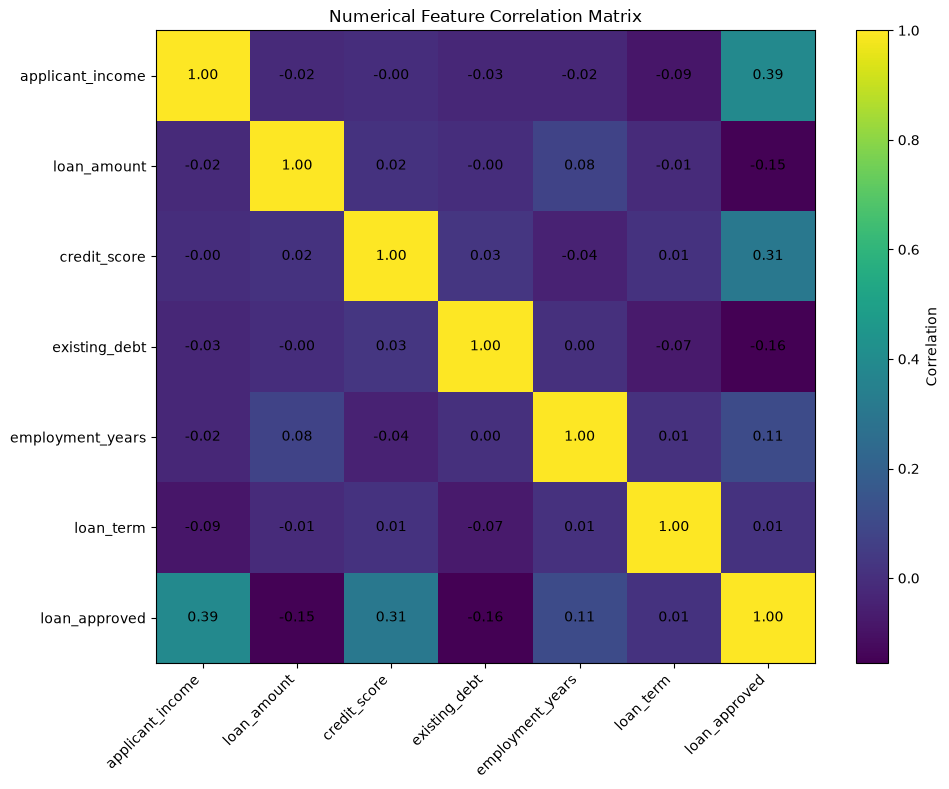

In [56]:
correlation_columns = (
    numerical_features
    + ["loan_approved"]
)

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    label="Correlation"
)

plt.xticks(
    range(len(correlation_columns)),
    correlation_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_columns)),
    correlation_columns
)

for row in range(
    len(correlation_columns)
):
    for column in range(
        len(correlation_columns)
    ):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

plt.title(
    "Numerical Feature Correlation Matrix"
)

plt.tight_layout()

plt.savefig(
    "reports/figures/correlation_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Model F1_score visualisation

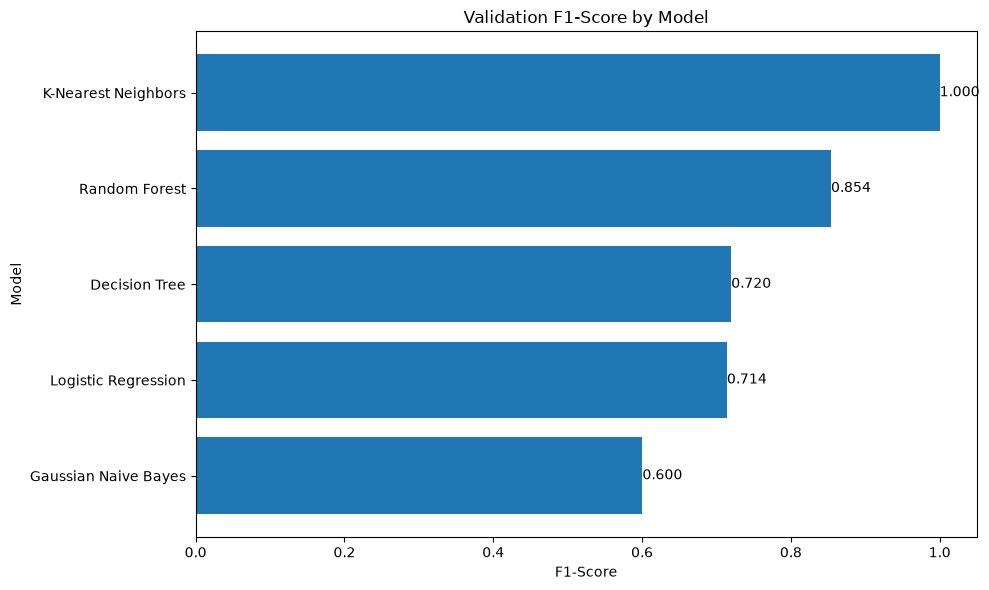

In [57]:
model_plot_df = (
    validation_results_df
    .sort_values("F1")
)

plt.figure(figsize=(10, 6))

plt.barh(
    model_plot_df["Model"],
    model_plot_df["F1"]
)

plt.title(
    "Validation F1-Score by Model"
)

plt.xlabel("F1-Score")
plt.ylabel("Model")

for index, value in enumerate(
    model_plot_df["F1"]
):
    plt.text(
        value,
        index,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/model_f1_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Model Roc_AUC Comparison

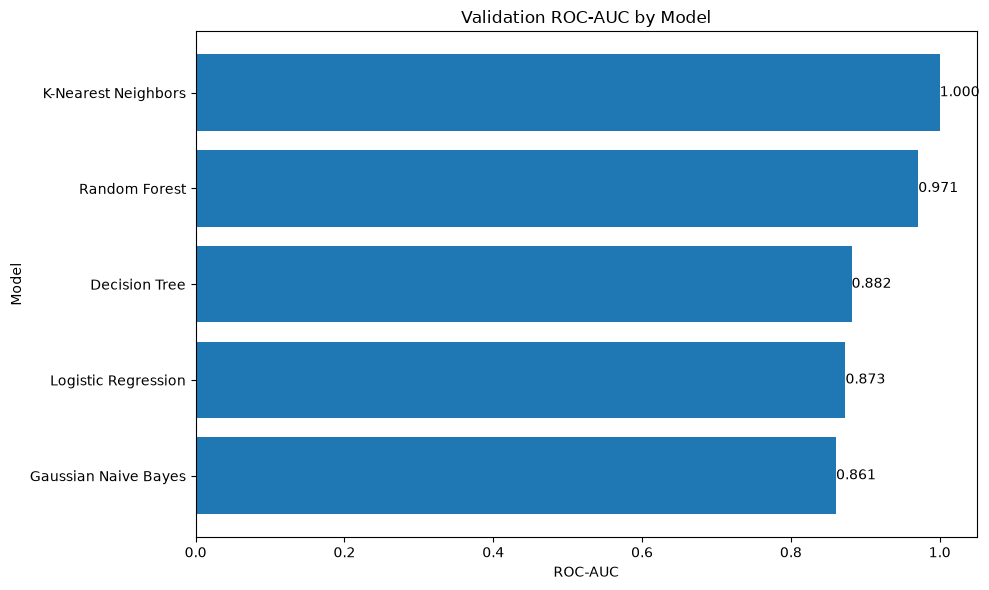

In [58]:
roc_auc_plot_df = (
    validation_results_df
    .sort_values("ROC_AUC")
)

plt.figure(figsize=(10, 6))

plt.barh(
    roc_auc_plot_df["Model"],
    roc_auc_plot_df["ROC_AUC"]
)

plt.title(
    "Validation ROC-AUC by Model"
)

plt.xlabel("ROC-AUC")
plt.ylabel("Model")

for index, value in enumerate(
    roc_auc_plot_df["ROC_AUC"]
):
    plt.text(
        value,
        index,
        f"{value:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    "reports/figures/model_roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Roc curves for all model

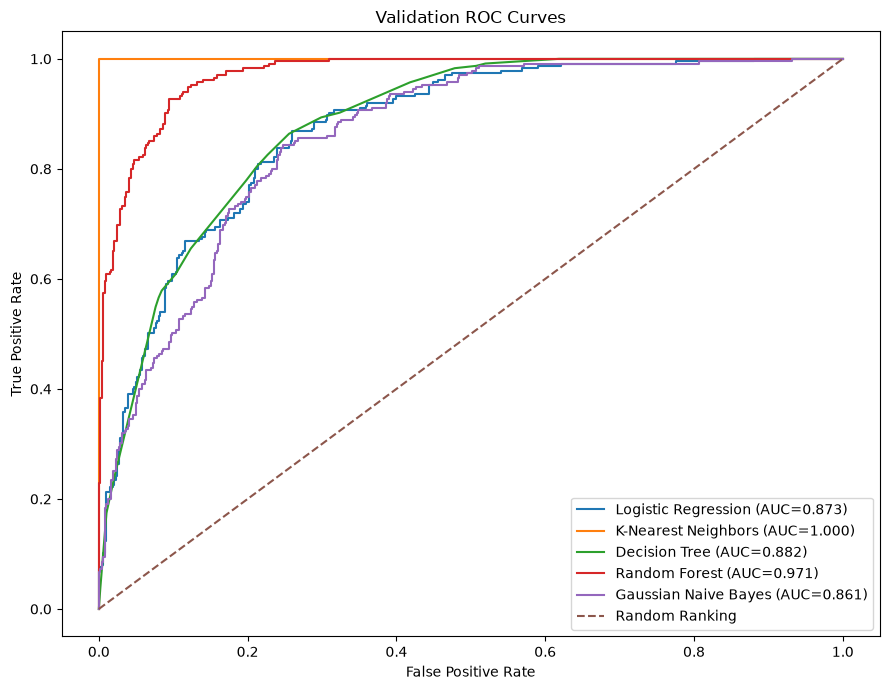

In [60]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score
)
plt.figure(figsize=(9, 7))

for model_name, fitted_pipeline in (
    trained_pipelines.items()
):
    probabilities = (
        get_positive_probabilities(
            fitted_pipeline,
            X_train_valid
        )
    )

    false_positive_rate, true_positive_rate, _ = (
        roc_curve(
            y_train_valid,
            probabilities
        )
    )

    auc_score = roc_auc_score(
        y_train_valid,
        probabilities
    )

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=(
            f"{model_name} "
            f"(AUC={auc_score:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Ranking"
)

plt.title(
    "Validation ROC Curves"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.tight_layout()

plt.savefig(
    "reports/figures/all_model_roc_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Final Confusion Matrix

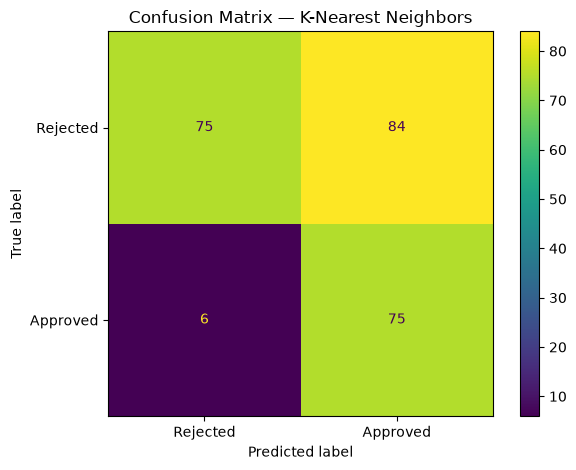

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=[
        "Rejected",
        "Approved"
    ],
    values_format="d"
)

plt.title(
    f"Confusion Matrix — {best_model_name}"
)

plt.tight_layout()

plt.savefig(
    "reports/figures/final_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Precision Recall and F1 across Threshhold

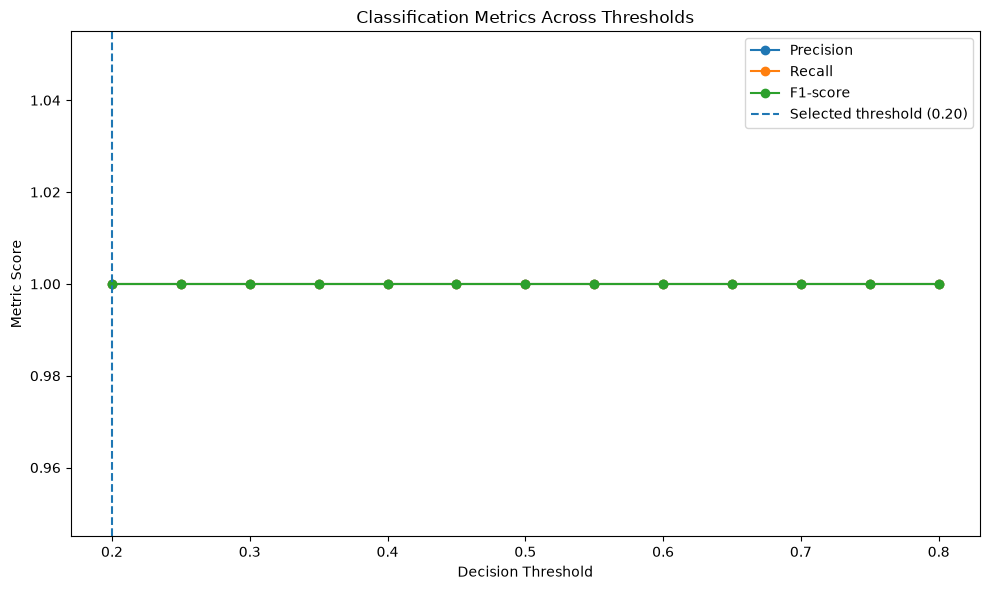

In [64]:
threshold_plot_df = (
    threshold_results_df
    .sort_values("Threshold")
)

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_plot_df["Threshold"],
    threshold_plot_df["F1"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=(
        f"Selected threshold "
        f"({best_threshold:.2f})"
    )
)

plt.title(
    "Classification Metrics Across Thresholds"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Metric Score")

plt.legend()
plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "threshold_metric_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

 ## Business Cost Across Threshold

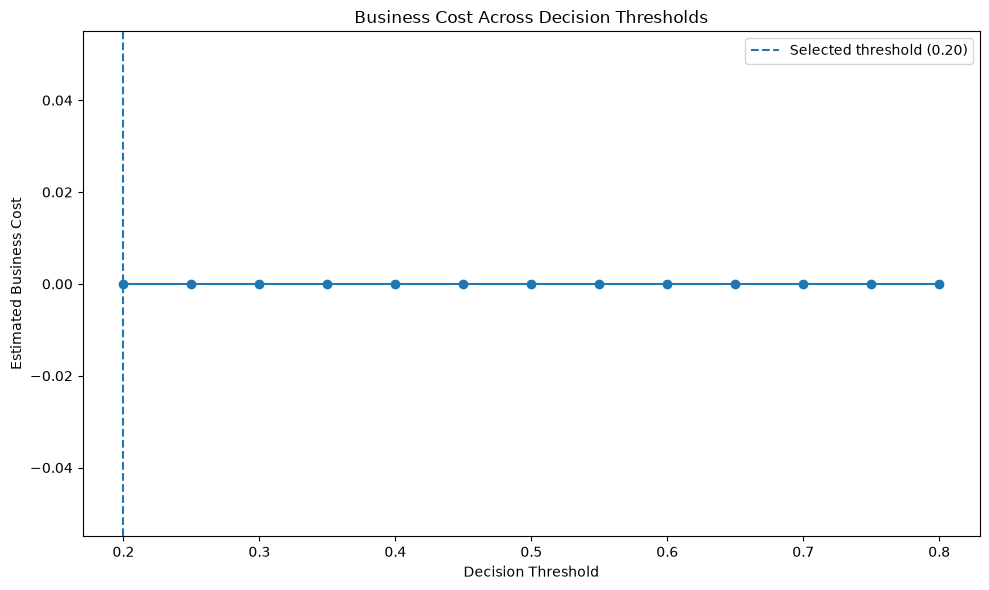

In [65]:
business_cost_df = (
    threshold_results_df
    .sort_values("Threshold")
)

plt.figure(figsize=(10, 6))

plt.plot(
    business_cost_df["Threshold"],
    business_cost_df["Business_Cost"],
    marker="o"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=(
        f"Selected threshold "
        f"({best_threshold:.2f})"
    )
)

plt.title(
    "Business Cost Across Decision Thresholds"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Estimated Business Cost")

plt.legend()
plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "threshold_business_cost.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## Random Forest Feature Importance

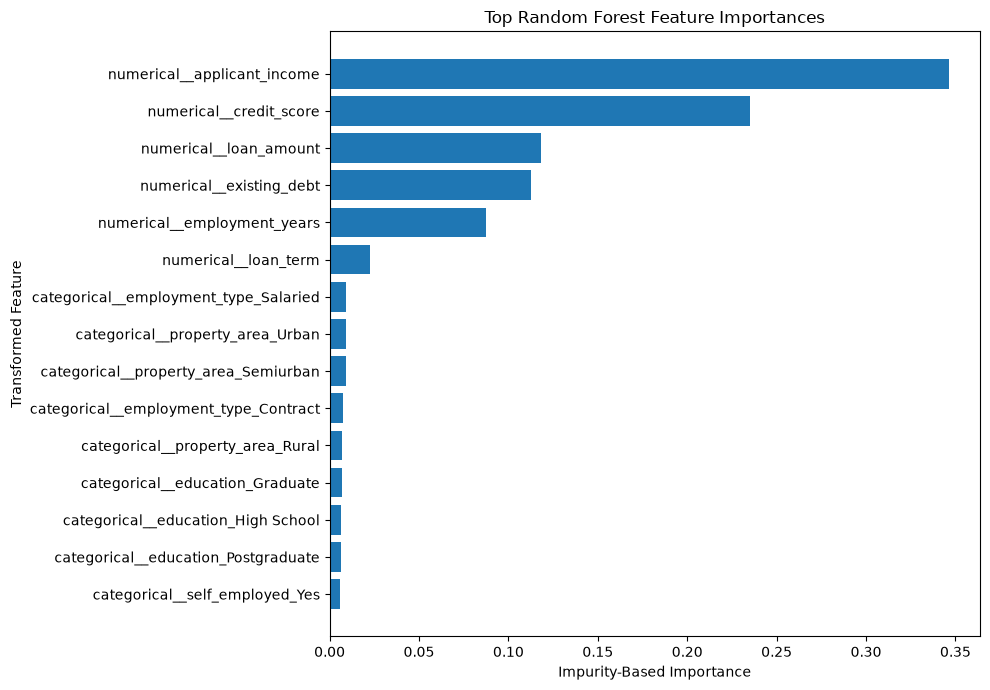

In [66]:
forest_pipeline = trained_pipelines[
    "Random Forest"
]

fitted_preprocessor = (
    forest_pipeline
    .named_steps["preprocessor"]
)

fitted_forest = (
    forest_pipeline
    .named_steps["model"]
)

transformed_feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)

feature_importance_df = pd.DataFrame({
    "Feature": transformed_feature_names,
    "Importance": (
        fitted_forest.feature_importances_
    )
}).sort_values(
    "Importance",
    ascending=False
)

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top Random Forest Feature Importances"
)

plt.xlabel("Impurity-Based Importance")
plt.ylabel("Transformed Feature")

plt.tight_layout()

plt.savefig(
    "reports/figures/"
    "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close()

## False Postive vs False Negative Count

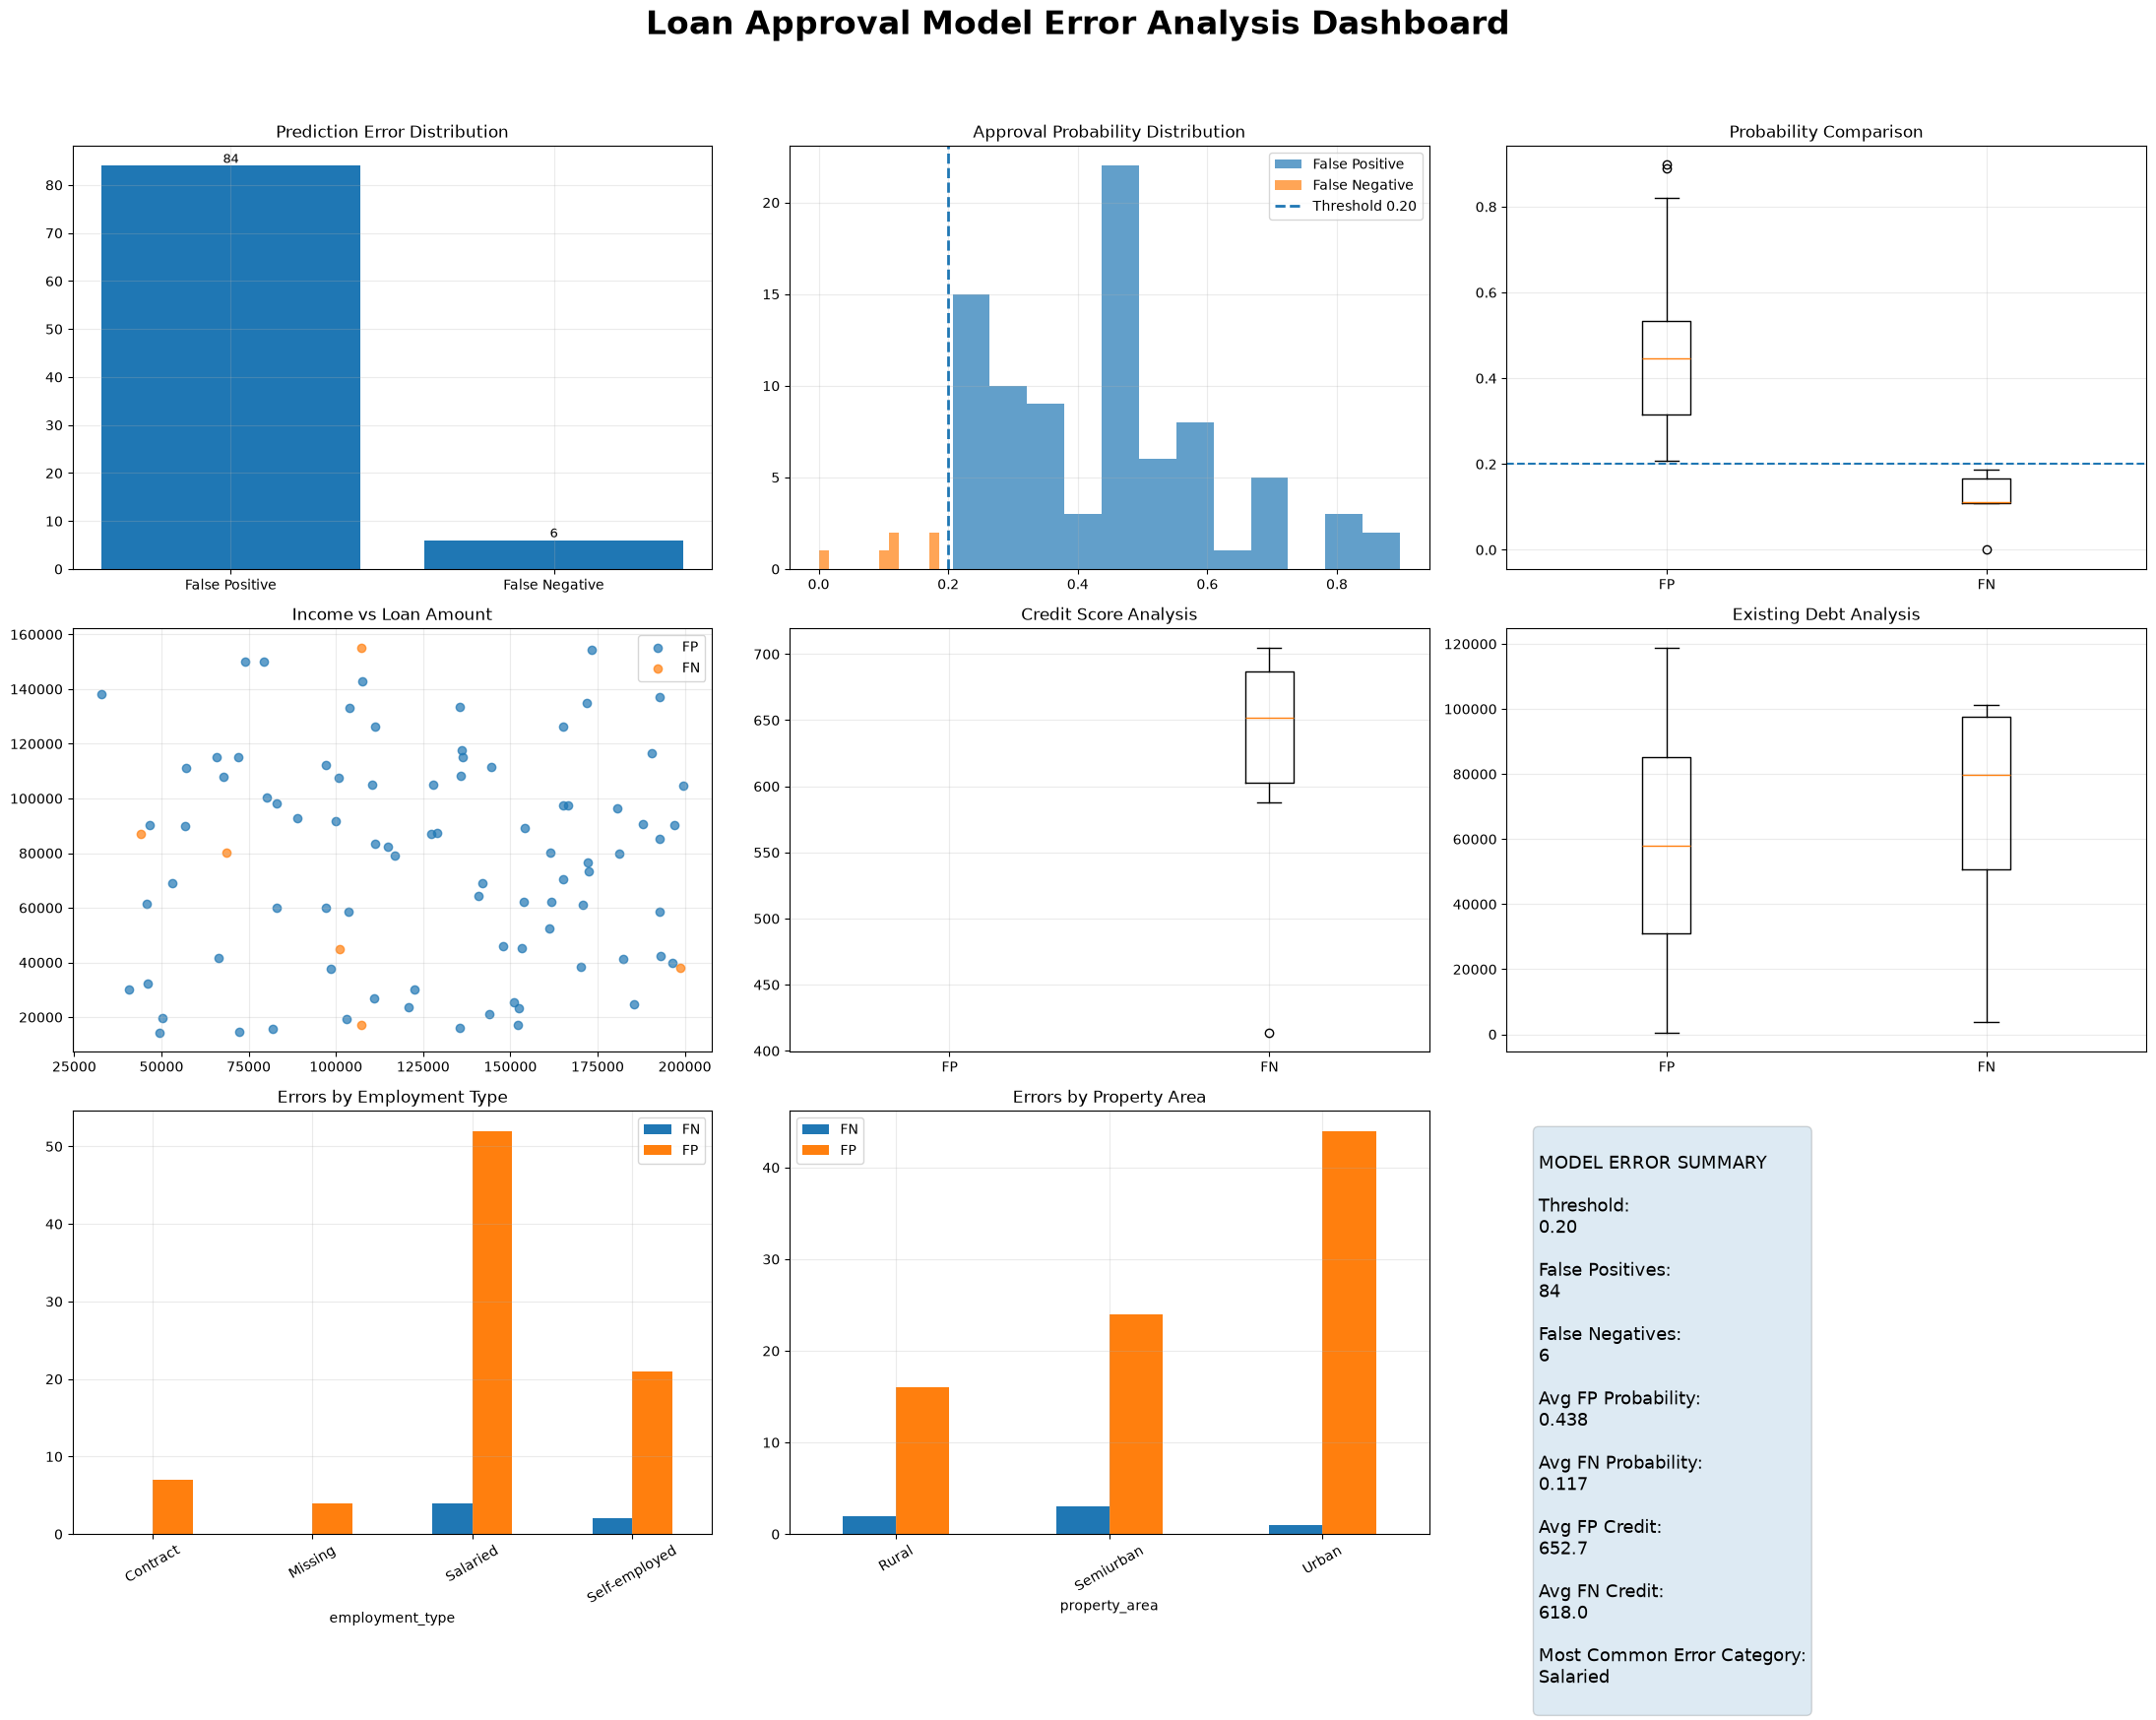

Dashboard saved: reports/figures/complete_error_analysis_dashboard.png


In [72]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def create_error_analysis_dashboard(
    error_analysis_df: pd.DataFrame,
    best_threshold: float,
    output_path: str = "reports/figures/complete_error_analysis_dashboard.png"
):

    required_columns = {
        "applicant_income",
        "loan_amount",
        "credit_score",
        "existing_debt",
        "employment_type",
        "property_area",
        "Prediction_Type",
        "Approval_Probability"
    }

    missing = required_columns.difference(
        error_analysis_df.columns
    )

    if missing:
        raise ValueError(
            f"Missing columns: {missing}"
        )

    if not 0 <= best_threshold <= 1:
        raise ValueError(
            "Threshold must be between 0 and 1"
        )


    errors_df = error_analysis_df[
        error_analysis_df["Prediction_Type"].isin(
            ["FP", "FN"]
        )
    ].copy()


    if errors_df.empty:
        raise ValueError(
            "No False Positive or False Negative found"
        )


    fp = errors_df[
        errors_df["Prediction_Type"] == "FP"
    ]

    fn = errors_df[
        errors_df["Prediction_Type"] == "FN"
    ]


    for df in [errors_df, fp, fn]:

        df["income_loan_ratio"] = (
            df["applicant_income"] /
            df["loan_amount"].replace(0,np.nan)
        )


    os.makedirs(
        os.path.dirname(output_path),
        exist_ok=True
    )


    plt.style.use(
        "default"
    )


    fig, axes = plt.subplots(
        3,
        3,
        figsize=(22,18)
    )


    fig.suptitle(
        "Loan Approval Model Error Analysis Dashboard",
        fontsize=24,
        fontweight="bold"
    )



    def add_labels(ax):

        for container in ax.containers:

            ax.bar_label(
                container,
                fontsize=9
            )



    ax = axes[0,0]


    counts = errors_df[
        "Prediction_Type"
    ].value_counts().reindex(
        ["FP","FN"],
        fill_value=0
    )


    bars=ax.bar(
        ["False Positive",
         "False Negative"],
        counts.values
    )


    ax.set_title(
        "Prediction Error Distribution"
    )


    add_labels(ax)



    ax = axes[0,1]


    if len(fp):

        ax.hist(
            fp["Approval_Probability"],
            bins=12,
            alpha=.7,
            label="False Positive"
        )


    if len(fn):

        ax.hist(
            fn["Approval_Probability"],
            bins=12,
            alpha=.7,
            label="False Negative"
        )


    ax.axvline(
        best_threshold,
        linestyle="--",
        linewidth=2,
        label=f"Threshold {best_threshold:.2f}"
    )


    ax.set_title(
        "Approval Probability Distribution"
    )

    ax.legend()



    ax = axes[0,2]


    ax.boxplot(
        [
            fp["Approval_Probability"],
            fn["Approval_Probability"]
        ],
        tick_labels=[
            "FP",
            "FN"
        ]
    )


    ax.axhline(
        best_threshold,
        linestyle="--"
    )


    ax.set_title(
        "Probability Comparison"
    )



    ax = axes[1,0]


    ax.scatter(
        fp["applicant_income"],
        fp["loan_amount"],
        label="FP",
        alpha=.7
    )


    ax.scatter(
        fn["applicant_income"],
        fn["loan_amount"],
        label="FN",
        alpha=.7
    )


    ax.set_title(
        "Income vs Loan Amount"
    )

    ax.legend()



    ax = axes[1,1]


    ax.boxplot(
        [
            fp["credit_score"],
            fn["credit_score"]
        ],
        tick_labels=[
            "FP",
            "FN"
        ]
    )


    ax.set_title(
        "Credit Score Analysis"
    )



    ax = axes[1,2]


    ax.boxplot(
        [
            fp["existing_debt"],
            fn["existing_debt"]
        ],
        tick_labels=[
            "FP",
            "FN"
        ]
    )


    ax.set_title(
        "Existing Debt Analysis"
    )



    def categorical_chart(
        ax,
        column,
        title
    ):


        data = pd.crosstab(
            errors_df[column].fillna("Missing"),
            errors_df["Prediction_Type"]
        )


        data.plot(
            kind="bar",
            ax=ax
        )


        ax.set_title(title)

        ax.tick_params(
            axis="x",
            rotation=30
        )


        ax.legend()



    categorical_chart(
        axes[2,0],
        "employment_type",
        "Errors by Employment Type"
    )


    categorical_chart(
        axes[2,1],
        "property_area",
        "Errors by Property Area"
    )



    ax = axes[2,2]

    ax.axis("off")


    summary = f"""
MODEL ERROR SUMMARY

Threshold:
{best_threshold:.2f}

False Positives:
{len(fp)}

False Negatives:
{len(fn)}

Avg FP Probability:
{fp['Approval_Probability'].mean():.3f}

Avg FN Probability:
{fn['Approval_Probability'].mean():.3f}

Avg FP Credit:
{fp['credit_score'].mean():.1f}

Avg FN Credit:
{fn['credit_score'].mean():.1f}

Most Common Error Category:
{errors_df['employment_type'].mode()[0]}
"""


    ax.text(
        0.05,
        0.95,
        summary,
        fontsize=13,
        va="top",
        bbox={
            "boxstyle":"round",
            "alpha":0.15
        }
    )



    for ax in axes.flatten():

        ax.grid(
            alpha=.25
        )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            .95
        ]
    )


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()

    plt.close()



    print(
        f"Dashboard saved: {output_path}"
    )



create_error_analysis_dashboard(
    error_analysis_df,
    best_threshold,
    "reports/figures/complete_error_analysis_dashboard.png"
)

## Diffenent model visualised

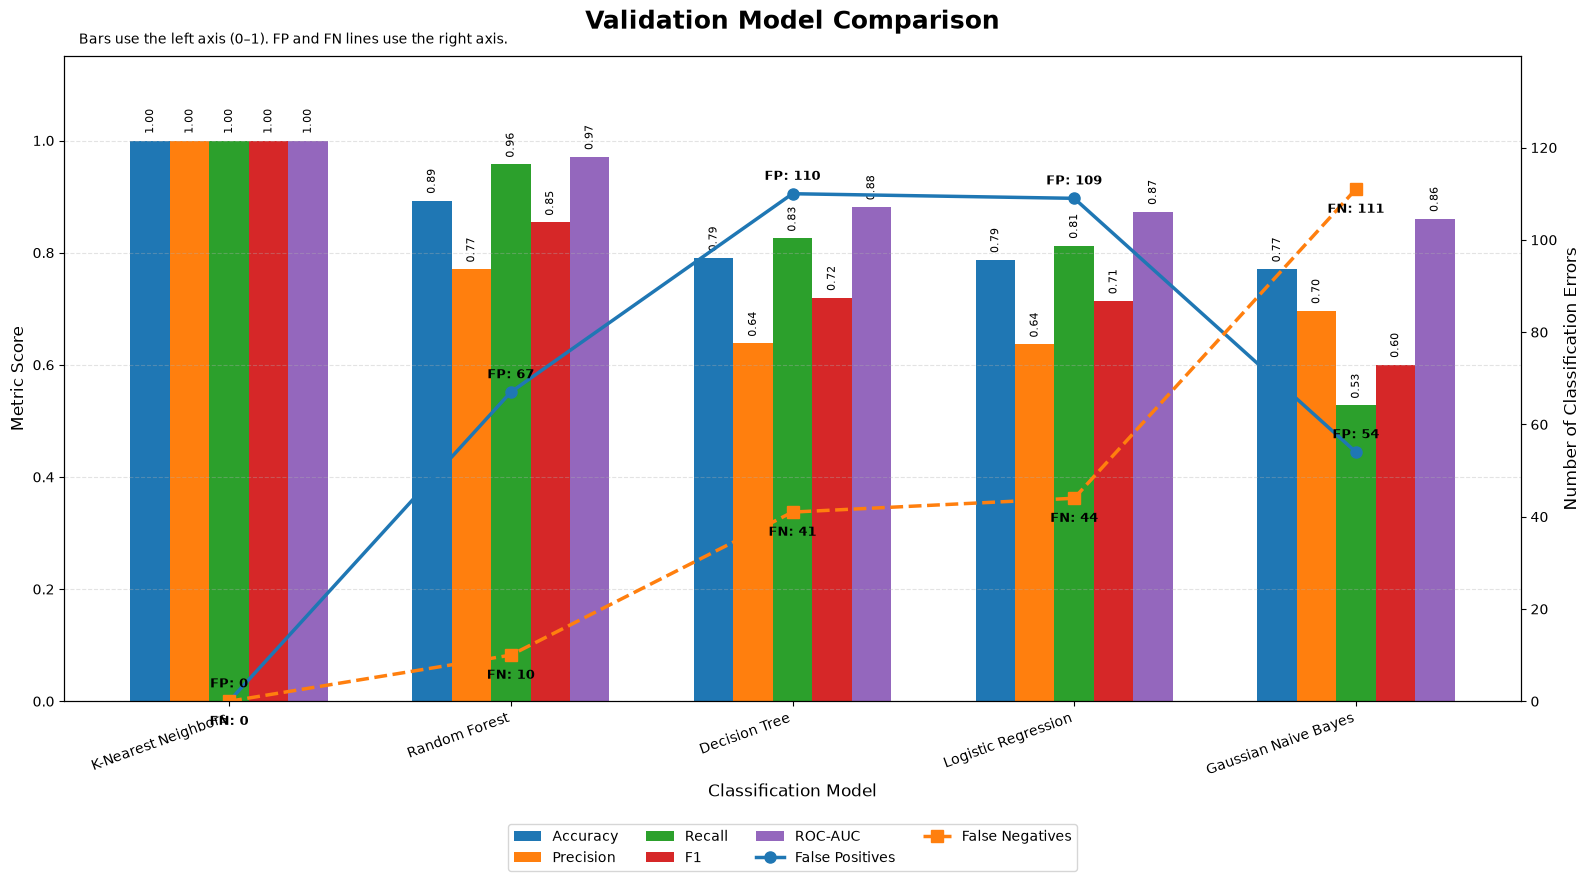

Complete model comparison graph saved to:
reports/figures/complete_model_comparison.png


In [73]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_complete_model_comparison(
    validation_results_df: pd.DataFrame,
    output_path: str = (
        "reports/figures/"
        "complete_model_comparison.png"
    ),
) -> None:
    """
    Visualize classification metrics and error counts
    for all models in one Matplotlib graph.

    Left y-axis:
        Accuracy, Precision, Recall, F1 and ROC-AUC

    Right y-axis:
        False Positives and False Negatives
    """

    required_columns = {
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
        "FP",
        "FN",
    }

    missing_columns = required_columns.difference(
        validation_results_df.columns
    )

    if missing_columns:
        raise ValueError(
            "Missing required columns: "
            + ", ".join(sorted(missing_columns))
        )

    # Create a clean copy and preserve the current model order.
    plot_df = (
        validation_results_df[
            [
                "Model",
                "Accuracy",
                "Precision",
                "Recall",
                "F1",
                "ROC_AUC",
                "FP",
                "FN",
            ]
        ]
        .copy()
        .reset_index(drop=True)
    )

    # Optional: sort models using ROC-AUC.
    plot_df = (
        plot_df
        .sort_values(
            "ROC_AUC",
            ascending=False,
        )
        .reset_index(drop=True)
    )

    metric_columns = [
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC_AUC",
    ]

    model_names = plot_df["Model"].tolist()
    x_positions = np.arange(len(model_names))

    # Width of every metric bar.
    bar_width = 0.14

    # Create only one figure and one plotting region.
    figure, metric_axis = plt.subplots(
        figsize=(16, 9)
    )

    # --------------------------------------------------
    # Plot Accuracy, Precision, Recall, F1 and ROC-AUC
    # --------------------------------------------------
    number_of_metrics = len(metric_columns)

    for metric_index, metric_name in enumerate(
        metric_columns
    ):
        offset = (
            metric_index
            - (number_of_metrics - 1) / 2
        ) * bar_width

        bars = metric_axis.bar(
            x_positions + offset,
            plot_df[metric_name],
            width=bar_width,
            label=metric_name.replace(
                "_",
                "-"
            ),
        )

        # Add values above every metric bar.
        for bar, value in zip(
            bars,
            plot_df[metric_name]
        ):
            metric_axis.text(
                bar.get_x()
                + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                rotation=90,
            )

    metric_axis.set_title(
        "Validation Model Comparison",
        fontsize=18,
        fontweight="bold",
        pad=20,
    )

    metric_axis.set_xlabel(
        "Classification Model",
        fontsize=12,
    )

    metric_axis.set_ylabel(
        "Metric Score",
        fontsize=12,
    )

    metric_axis.set_ylim(
        0,
        1.15,
    )

    metric_axis.set_xticks(
        x_positions
    )

    metric_axis.set_xticklabels(
        model_names,
        rotation=20,
        ha="right",
    )

    metric_axis.grid(
        axis="y",
        linestyle="--",
        alpha=0.35,
    )

    # --------------------------------------------------
    # Secondary y-axis for FP and FN counts
    # --------------------------------------------------
    error_axis = metric_axis.twinx()

    fp_line = error_axis.plot(
        x_positions,
        plot_df["FP"],
        marker="o",
        linewidth=2.5,
        markersize=8,
        label="False Positives",
    )

    fn_line = error_axis.plot(
        x_positions,
        plot_df["FN"],
        marker="s",
        linewidth=2.5,
        markersize=8,
        linestyle="--",
        label="False Negatives",
    )

    error_axis.set_ylabel(
        "Number of Classification Errors",
        fontsize=12,
    )

    maximum_error = max(
        plot_df["FP"].max(),
        plot_df["FN"].max(),
    )

    error_axis.set_ylim(
        0,
        maximum_error * 1.25 + 1,
    )

    # Add FP and FN values near line markers.
    for x_value, fp_value in zip(
        x_positions,
        plot_df["FP"],
    ):
        error_axis.annotate(
            f"FP: {int(fp_value)}",
            xy=(x_value, fp_value),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    for x_value, fn_value in zip(
        x_positions,
        plot_df["FN"],
    ):
        error_axis.annotate(
            f"FN: {int(fn_value)}",
            xy=(x_value, fn_value),
            xytext=(0, -17),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            fontweight="bold",
        )

    # --------------------------------------------------
    # Combine legends from both axes
    # --------------------------------------------------
    metric_handles, metric_labels = (
        metric_axis.get_legend_handles_labels()
    )

    error_handles, error_labels = (
        error_axis.get_legend_handles_labels()
    )

    metric_axis.legend(
        metric_handles + error_handles,
        metric_labels + error_labels,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.18),
        ncol=4,
        frameon=True,
    )

    # Add an explanation inside the graph.
    metric_axis.text(
        0.01,
        1.02,
        (
            "Bars use the left axis (0–1). "
            "FP and FN lines use the right axis."
        ),
        transform=metric_axis.transAxes,
        fontsize=10,
    )

    plt.tight_layout()

    output_directory = os.path.dirname(
        output_path
    )

    if output_directory:
        os.makedirs(
            output_directory,
            exist_ok=True,
        )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    print(
        "Complete model comparison graph saved to:"
    )
    print(output_path)


# Run after validation_results_df is created.
plot_complete_model_comparison(
    validation_results_df,
    output_path=(
        "reports/figures/"
        "complete_model_comparison.png"
    ),
)